# Why bother learning recursion and iteration, if they are so much worse in time than other ways?

This week, we move on further analysing what makes certain implementation style of an algorithm more complex and less efficient than other style of implementing the same algorithm.

We will also introduce ways to
1) Visualise algorithmic processes, including iteration / recursion trees.
2) Visualise other measures of algorithmic efficiency with different tools in Python
3) Choose a strategy in algorithm design


# Some analytics tools and how to install them in Jupyter

Jupyter magical functions
https://ipython.readthedocs.io/en/stable/interactive/magics.html

We have already been using **%%timeit** magical function to measure average running time of certain algorithms.
There are also other fancy tools to be used. Here, I will be using %%heat, which is a cell-magic function, meaning that it is analysing a certain cell. The **%%heat** command must be at the very beginning of a cell, and you have to use the command %load_ext heat, or %reload_ext heat to make use of %%heat. https://pypi.org/project/py-heat-magic/

Some further analysis tools are mentioned here, give them a try: https://towardsdatascience.com/speed-up-jupyter-notebooks-20716cbe2025, or https://jakevdp.github.io/PythonDataScienceHandbook/01.07-timing-and-profiling.html

## Algorithm design strategies

* Greedy
    * Choosing the optimal solution at each step
* Backtracking
    * Recursion in depth-first manner
    * Return a solution when its found
* Divide and conquer
    * Solve a large problem by recursively breaking it down into smaller subproblems until they can be solved directly.
* Dynamic programming
    *  Simplifying a complicated problem by breaking it down into simpler sub-problems in a recursive manner
* Brute force
    * Solve problem through exhaustion - try all possible choices until solution is found
* Heuristic
    * Sort of guessing the near-optimal solution without any proper analysis



In [7]:
%reload_ext heat

## 1. Example of a backtracking algorithm

Consider a number sequence1 which is formed in the following manner:

$$A_n = 2\cdot A_{n-1} +1 \text{, }A_1 = 1$$

The number sequence is thus

$$A_1 = 1 $$ $$A_2 = 2\cdot 1+1 = 2 +1 = 3$$ $$A_3 = 2\cdot A_2 + 1 = 2\cdot 3 +1 = 7 $$ $$ \ldots$$

Let's write in-depth style algorithm that computes the nth element in this number sequence. Why is it in-depth/ backtracking?

Let's compare this to another number sequence implemented in same manner: The number sequence is defined as follows: $$a_n = 3\cdot a_{n-1}+a_{n-2} \text{ , and } a_1 = -1 \text{ , } a_2 = 2$$

SEE THIS VISUALISATION: https://recursion.vercel.app/
NOTE ALSO: there's no use of memoization / dynamic programming in this example

Sequence 1: 
1
3
7
15
31
63
127
255
511
1023
2047
4095
8191
16383
Sequence 2: 
-1
2
5
17
56
185
611
2018
6665
22013
72704
240125
793079
2619362


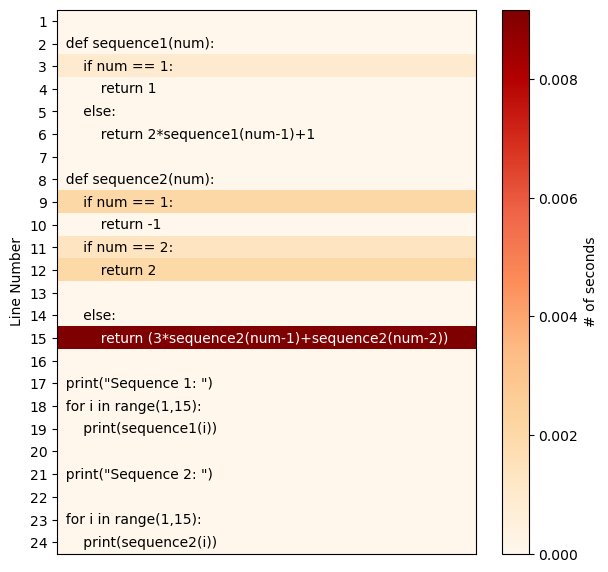

In [41]:
%%heat

def sequence1(num):
    if num == 1:
        return 1
    else:
        return 2*sequence1(num-1)+1

def sequence2(num):
    if num == 1:
        return -1 
    if num == 2:
        return 2
    
    else:
        return (3*sequence2(num-1)+sequence2(num-2))

print("Sequence 1: ")    
for i in range(1,15):
    print(sequence1(i))
          
print("Sequence 2: ")

for i in range(1,15):
    print(sequence2(i))

## 2. Example of dynamic programming - using memoization

Let's consider the second number sequence $$a_n = 3\cdot a_{n-1}+a_{n-1} \text{ , and } a_1 = -1 \text{ , } a_2=2 $$

Let's have a look at the recursion tree of the original recursive implementation of this number sequence: 
https://recursion.vercel.app/

It seems that the algorithm does quite a lot extra work. There are many values that could be saved and then simply returned from memory once they are computed. Let's introduce dynamic programming / memoization strategy to see, how dramatically the workload changes. 


Sequence 2: 
-1
2
5
17
56
185
611
2018
6665
22013
72704
240125
793079
2619362


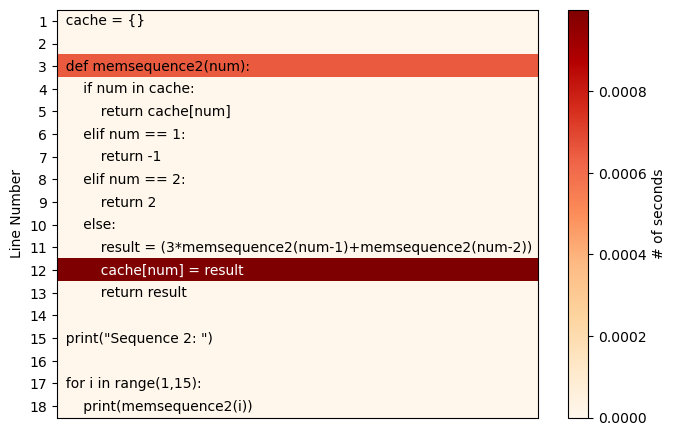

In [29]:
%%heat
cache = {}

def memsequence2(num):
    if num in cache:
        return cache[num]
    elif num == 1:
        return -1 
    elif num == 2:
        return 2
    else:
        result = (3*memsequence2(num-1)+memsequence2(num-2))
        cache[num] = result
        return result

print("Sequence 2: ")

for i in range(1,15):
    print(memsequence2(i))

## 3. Example of a brute-force algorithm

Consider the task of finding all factors of a given natural number.

One way to implement this is simply going through all possible factors up to the square root of the given number. Why is it brute-force? You exhaustively test whether a number is a factor of the given number, one by one.

[1, 3, 7, 9, 11, 13, 21, 27, 33, 37, 39, 63, 77, 91, 99, 111, 117, 143, 189, 231, 259, 273, 297, 333, 351, 407, 429, 481, 693, 777, 819, 999, 1001, 1221, 1287, 1443, 2079, 2331, 2457, 2849, 3003, 3367, 3663, 3861, 4329, 5291, 6993, 8547, 9009, 10101, 10989, 12987, 15873, 25641, 27027, 30303, 37037, 47619, 76923, 90909, 111111, 142857, 333333, 999999]


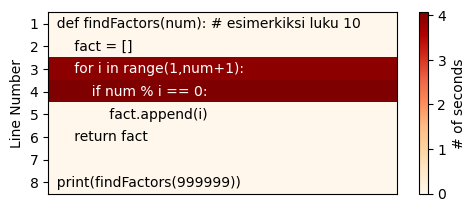

In [53]:
%%heat
def findFactors(num): # esimerkiksi luku 10
    fact = []
    for i in range(1,num+1):
        if num % i == 0:
            fact.append(i)
    return fact

print(findFactors(999999))

[1, 3, 7, 9, 11, 13, 21, 27, 33, 37, 39, 63, 77, 91, 99, 111, 117, 143, 189, 231, 259, 273, 297, 333, 351, 407, 429, 481, 693, 777, 819, 999, 1001, 1221, 1287, 1443, 2079, 2331, 2457, 2849, 3003, 3367, 3663, 3861, 4329, 5291, 6993, 8547, 9009, 10101, 10989, 12987, 15873, 25641, 27027, 30303, 37037, 47619, 76923, 90909, 111111, 142857, 333333, 999999]


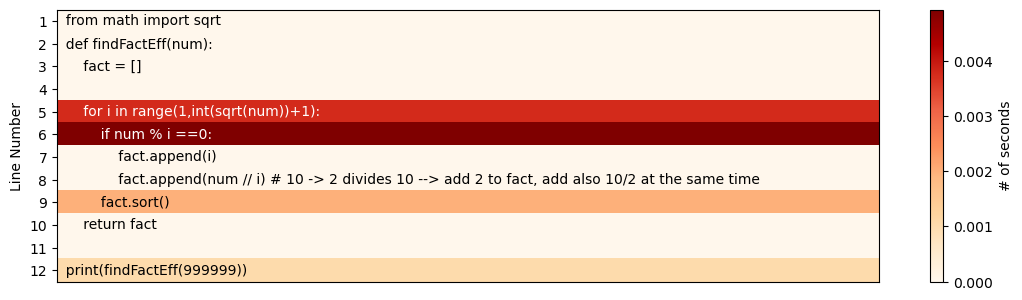

In [56]:
%%heat
from math import sqrt
def findFactEff(num):
    fact = []
    
    for i in range(1,int(sqrt(num))+1):
        if num % i ==0:
            fact.append(i)
            fact.append(num // i) # 10 -> 2 divides 10 --> add 2 to fact, add also 10/2 at the same time
        fact.sort()
    return fact
    
print(findFactEff(999999))

## 4. Example of a divide-and-conquer algorithm

Merge sort
https://www.geeksforgeeks.org/merge-sort/

Modular exponentiation
https://www.geeksforgeeks.org/modular-exponentiation-power-in-modular-arithmetic/


Given array is
12 11 13 5 6 7 
Sorted array is: 
5 6 7 11 12 13 


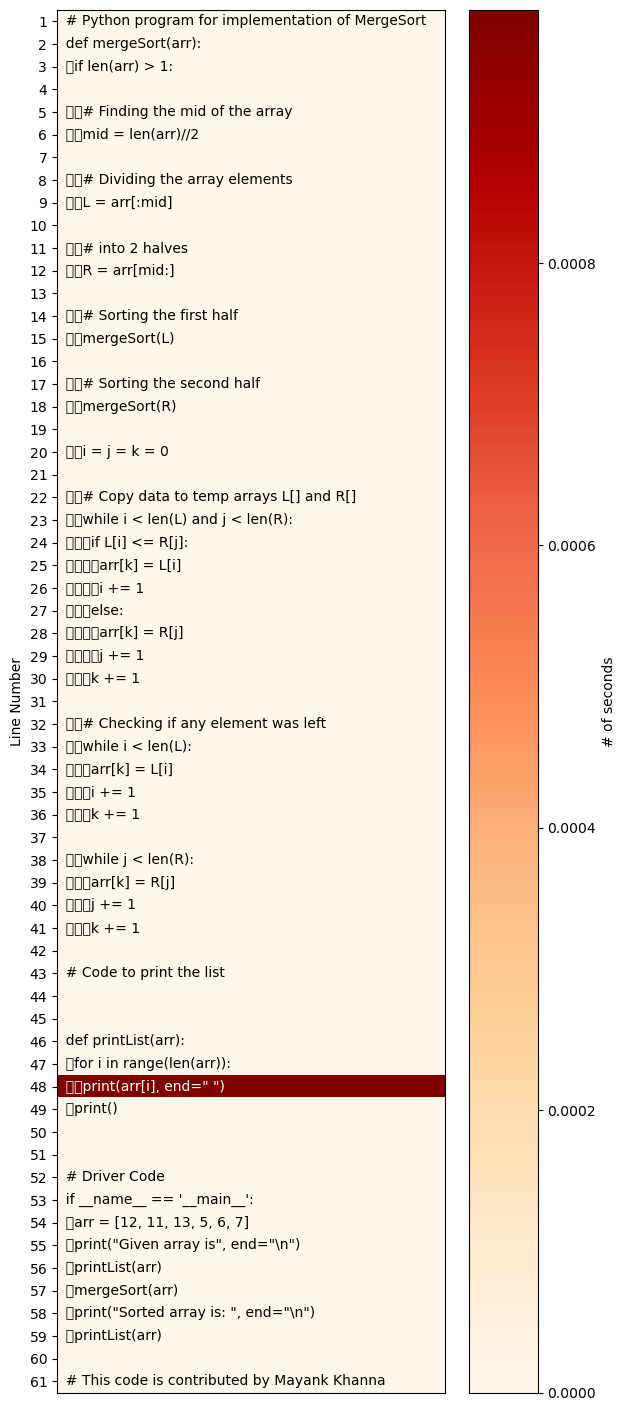

In [51]:
%%heat
# Python program for implementation of MergeSort
def mergeSort(arr):
	if len(arr) > 1:

		# Finding the mid of the array
		mid = len(arr)//2

		# Dividing the array elements
		L = arr[:mid]

		# into 2 halves
		R = arr[mid:]

		# Sorting the first half
		mergeSort(L)

		# Sorting the second half
		mergeSort(R)

		i = j = k = 0

		# Copy data to temp arrays L[] and R[]
		while i < len(L) and j < len(R):
			if L[i] <= R[j]:
				arr[k] = L[i]
				i += 1
			else:
				arr[k] = R[j]
				j += 1
			k += 1

		# Checking if any element was left
		while i < len(L):
			arr[k] = L[i]
			i += 1
			k += 1

		while j < len(R):
			arr[k] = R[j]
			j += 1
			k += 1

# Code to print the list


def printList(arr):
	for i in range(len(arr)):
		print(arr[i], end=" ")
	print()


# Driver Code
if __name__ == '__main__':
	arr = [12, 11, 13, 5, 6, 7]
	print("Given array is", end="\n")
	printList(arr)
	mergeSort(arr)
	print("Sorted array is: ", end="\n")
	printList(arr)

# This code is contributed by Mayank Khanna

Power is  6


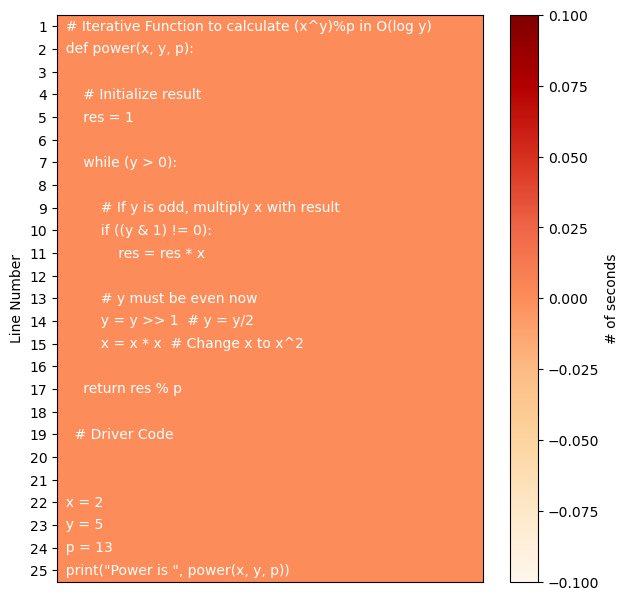

In [35]:
%%heat
# Iterative Function to calculate (x^y)%p in O(log y)
def power(x, y, p):
 
    # Initialize result
    res = 1
 
    while (y > 0):
 
        # If y is odd, multiply x with result
        if ((y & 1) != 0):
            res = res * x
 
        # y must be even now
        y = y >> 1  # y = y/2
        x = x * x  # Change x to x^2
 
    return res % p
 
  # Driver Code
 
 
x = 2
y = 5
p = 13
print("Power is ", power(x, y, p))

## Example of a greedy algorithm

Greedy algorithms try to find locally optimal solutions (that feel the best right now) but they might miss the globally optimal solutions (that would have been the best overall).

In the link below, there's an example of a money vending algorithm that's greedy. There's also a good example how the algorithm mostly works in an efficient way, finding the globally best solution by finding the locally best solution. But there are inputs for which the algorithm fails to find the globally optimal solution for the change money. Let's have a look at the algorithm and these different cases.

https://skerritt.blog/greedy-algorithms/

In [40]:
denominations = [1, 2, 5, 10, 15, 20, 50, 100]
# 100p is £1

def returnChange(change, denominations):
    # makes a list size of length denominations filled with 0
    toGiveBack = [0] * len(denominations)

    # goes backwards through denominations list
    # and also keeps track of the counter, pos.
    for pos, coin in enumerate(reversed(denominations)):
        # while we can still use coin, use it until we can't
        while coin <= change:
            change = change - coin
            toGiveBack[pos] += 1
    return(toGiveBack)
            
print(returnChange(30, denominations))

# returns [0, 0, 0, 1, 1, 0, 0]
# 1x 10p, 1x 20p

print(returnChange(75, denominations))
# returns [0, 1, 1, 0, 1, 0, 0]
# 1 x 5p, 1 x 20p, 1 x 50p

print(returnChange(150, denominations))
# returns [1, 1, 0, 0, 0, 0, 0]
# 1 x 100p, 1 x 50p

#Code by: Autumn Skerrit

[0, 0, 1, 1, 0, 0, 0]
[0, 1, 1, 0, 1, 0, 0]
[1, 1, 0, 0, 0, 0, 0]


## 6. Heuristic algorithms
An example of a heuristic algorithm of choosing the most expensive toys to a toychest
https://www.youtube.com/watch?v=Jd-KutOljto

An example of using heuristic search in AI & games:
https://www.youtube.com/watch?v=9UGAIcxQHRU

This will be of future interest!

## Some further tools to analyse iterative algorithms

tqdm package:
https://tqdm.github.io/


In [57]:
from tqdm.notebook import trange, tqdm
from time import sleep


for i in trange(4): #first loop
    for j in tqdm(range(100)): #Nested loop
        sleep(0.01)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

## Articles for further studying

**Visualising algorithms**

[1] https://medium.com/@isohale/visualizing-algorithms-precedents-part-1-ce3f230d0329

[2] https://bost.ocks.org/mike/algorithms/

[3] https://towardsdatascience.com/speed-up-jupyter-notebooks-20716cbe2025